In [ ]:
# For local development: Download the dataset manually and place in ./data/ folder
# Dataset: https://www.kaggle.com/datasets/snmahsa/animal-image-dataset-cats-dogs-and-foxes
# 
# Instructions:
# 1. Download the dataset from Kaggle
# 2. Extract it to a ./data/ folder in the same directory as this notebook
# 3. The folder structure should be: ./data/cats/, ./data/dogs/, ./data/foxes/

try:
    from google.colab import files  # type: ignore
    # For Google Colab, uncomment the line below and upload kaggle.json
    # files.upload()  # select kaggle.json from your local
except ImportError:
    print("Not running in Google Colab. Ensure dataset is in ./data/ folder.")

Saving kaggle.json to kaggle.json


{'kaggle.json': b'KGAT_21328233a3b0a777453c3a700f1c732c'}

In [ ]:
import json
import os

# Create .kaggle directory
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Load credentials from environment or prompt user
# FOR SECURITY: Add your kaggle.json file to ~/.kaggle/ directory manually
# Or set KAGGLE_USERNAME and KAGGLE_KEY environment variables

# Example (do not hardcode credentials in notebook):
# kaggle_json = {
#   "username":"your_username",
#   "key":"your_api_key"
# }
# with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
#     json.dump(kaggle_json, f)
# os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

In [25]:
!kaggle datasets list -s "dog and cat"


ref                                                        title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
tongpython/cat-and-dog                                     Cat and Dog                                          228487605  2018-04-26 10:56:50.843000         186527       1512  0.75             
andrewmvd/dog-and-cat-detection                            Dog and Cat Detection                               1104710460  2020-05-12 20:46:17.613000          11141        117  0.875            
marquis03/cats-and-dogs                                    Cats and Dogs                                         10219362  2023-10-27 10:48:19.220000          12545        122  1.0              
mmoreaux/audio-cats-and-d

In [26]:
# Download the dataset via Kaggle API
!kaggle datasets download -d snmahsa/animal-image-dataset-cats-dogs-and-foxes

# Create a data folder
!mkdir -p ./data

# Unzip into the data folder
!unzip -q animal-image-dataset-cats-dogs-and-foxes.zip -d ./data


Dataset URL: https://www.kaggle.com/datasets/snmahsa/animal-image-dataset-cats-dogs-and-foxes
License(s): other
 94% 366M/388M [00:02<00:00, 152MB/s]
100% 388M/388M [00:02<00:00, 150MB/s]


In [29]:
import os
import shutil
from glob import glob

# Original folder
src_folder = "./data/Animal Image Dataset-Cats, Dogs, and Foxes"

# Create class folders
for cls in ["cats", "dogs", "foxes"]:
    os.makedirs(f"./data/{cls}", exist_ok=True)

# Move files into correct folders based on filename
for file_path in glob(os.path.join(src_folder, "*")):
    fname = os.path.basename(file_path).lower()
    if "cat" in fname:
        shutil.move(file_path, "./data/cats/")
    elif "dog" in fname:
        shutil.move(file_path, "./data/dogs/")
    elif "fox" in fname:
        shutil.move(file_path, "./data/foxes/")


In [ ]:
from tensorflow import keras

# Image size and batch size
ROWS, COLS = 128, 128
BATCH_SIZE = 32

# Data augmentation + normalization
datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 20% validation
    horizontal_flip=True,
    rotation_range=20
)

# Training generator
train_generator = datagen.flow_from_directory(
    './data',
    target_size=(ROWS, COLS),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # for multi-class
    subset='training',
    shuffle=True
)

# Validation generator
validation_generator = datagen.flow_from_directory(
    './data',
    target_size=(ROWS, COLS),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Check class indices
print("Class mapping:", train_generator.class_indices)

Found 247 images belonging to 1 classes.
Found 61 images belonging to 1 classes.
Class mapping: {'Animal Image Dataset-Cats, Dogs, and Foxes': 0}


In [ ]:
from tensorflow import keras

# Define the CNN
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(ROWS, COLS, 3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(3, activation='softmax')  # 3 classes
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3384 - loss: 1.4988

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 78s 9s/step - accuracy: 0.3408 - loss: 1.4819 - val_accuracy: 0.3934 - val_loss: 1.0857
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 70s 9s/step - accuracy: 0.3164 - loss: 1.1011 - val_accuracy: 0.4262 - val_loss: 1.0822
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 67s 8s/step - accuracy: 0.4385 - loss: 1.0804 - val_accuracy: 0.3934 - val_loss: 1.0737
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 9s/step - accuracy: 0.4623 - loss: 1.0518 - val_accuracy: 0.4426 - val_loss: 1.0906
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 73s 9s/step - accuracy: 0.4523 - loss: 1.0451 - val_accuracy: 0.3607 - val_loss: 1.1741
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 72s 9s/step - accuracy: 0.4063 - loss: 1.0485 - val_accuracy: 0.4590 - val_loss: 1.0933
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 70s 9s/step - accuracy: 0.6079 - loss: 0.9524 - val_accuracy: 0.4262 - val_loss: 1.0290
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 75s 10s/step - accuracy: 0.5452 - loss: 0.9120 - val_accuracy: 0.4098 - val_loss: 1.0476
Epoch 9/10
8/8 ━━━

In [36]:
val_loss, val_acc = model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6122 - loss: 0.9207
Validation Accuracy: 59.02%


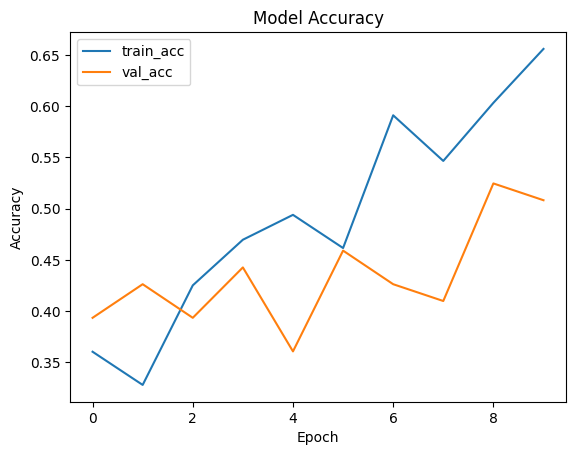

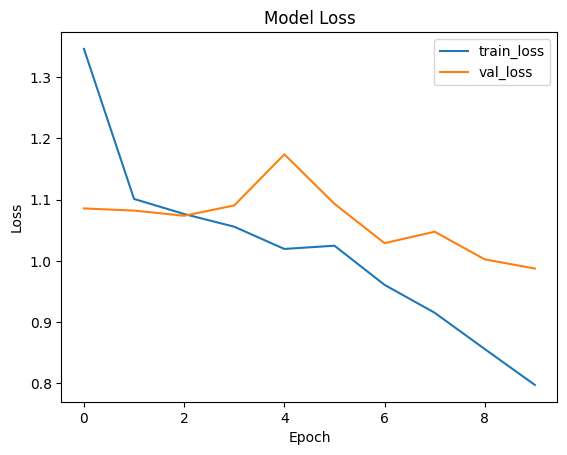

In [37]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [38]:
# Save entire model
model.save("cats_dogs_foxes_model.h5")
